In [1]:
# student_id = #####
# print(f"Modulo of student ID by 4: {student_id % 4}")

# Modulo of student ID by 4: 0

### So, I will be working with the following data:

- The paper “Risk Behavior, Decision-Making, and Music Genre in Adolescent Males” (Marshall University, May 2009) examined the effect of type of music playing and performance on a risky, decision-making task. Participants in the study responded to a questionnaire that was used to assign a risk behavior score. Risk behavior scores (read from a graph that appeared in the paper) for 15 participants follow.

    102 105 113 120 125 127 134 135 139 141 144 145 149 150 160

 - In Table 1 there are data of systolic blood pressure (mmHg) of 25 healthy subjects (status=0) and 30 subjects with hypertension (status=1)

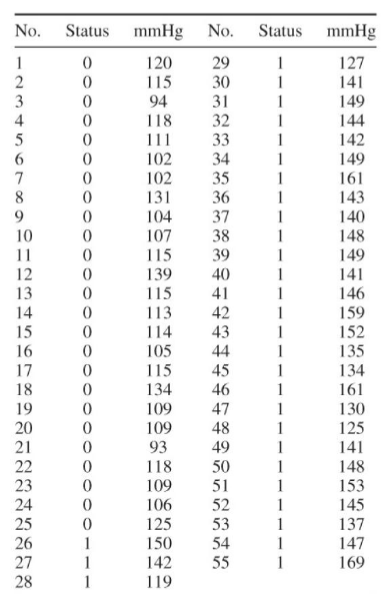

In [2]:
# Importing necessary libraries
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

In [3]:
# Defining the data from two datasets
# Dataset 1: Risk behavior scores
case1_data = np.array([102, 105, 113, 120, 125, 127, 134, 135, 139, 141, 144, 145, 149, 150, 160])

# Dataset 2: Systolic blood pressure for healthy subjects and subjects with hypertension
case2_data = np.array([
    120, 115, 94, 118, 111, 102, 102, 131, 104, 107,
    115, 139, 115, 113, 114, 105, 115, 134, 109, 109,
    93, 118, 109, 106, 125, 150, 142, 119, 127, 141,
    149, 144, 142, 149, 161, 143, 140, 148, 149, 141,
    146, 159, 152, 135, 134, 161, 130, 125, 141, 148,
    153, 145, 137, 147, 169])

In [4]:
# Define significance levels for hypothesis testing
alphas = [0.05, 0.1]

In [5]:
def perform_hypothesis_test(data, case_name, case):
    n = len(data)  # sample size
    df = n - 1  # degrees of freedom
    x_bar = np.mean(data)  # sample mean

    # Use the sample standard deviation s instead of sigma
    s = np.std(data, ddof=1)

    # Calculate the mean of the given sample and choose the assumed value of the population mean
    mu_0 = 131 if case == 0 else 151

    # Compute the t-statistic using the sample data
    t_stat = (x_bar - mu_0) / (s / np.sqrt(n))

    # Calculate the p-value using the t-distribution
    # Accounts for both tails of the distribution in a two-tailed test
    p_value = 2 * (1 - stats.t.cdf(abs(t_stat), df))

    print(f"=== {case_name} ===")
    print(f"N = {n}, df = {df}")
    print(f"Hypothesized population mean (mu_0) = {mu_0}")
    print(f"Sample mean (x_bar) = {x_bar:.2f}")
    print(f"t-statistic = {t_stat:.4f}")
    print(f"P-value = {p_value:.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    for i, alpha in enumerate(alphas):
        # Establish the critical regions based on the chosen significance level
        t_crit = stats.t.ppf(1 - alpha / 2, df)
        non_rejection_region = (-t_crit, t_crit)

        print(f"\nFor Alpha = {alpha}:")
        print(f"Non-rejection region: [{non_rejection_region[0]:.4f}, {non_rejection_region[1]:.4f}]")

        # Compare the calculated test statistic with critical values to make a decision
        if abs(t_stat) > t_crit:
            print("Decision: Reject H_0 (p-value < alpha)")
        else:
            print("Decision: Fail to reject the null hypothesis")

        # Visualize the distribution of the test statistic, critical regions, and the observed data
        ax = axes[i]
        x_vals = np.linspace(-4, 4, 1000)
        y_vals = stats.t.pdf(x_vals, df)
        ax.plot(x_vals, y_vals, label=f't-dist (df={df})')

        # Highlighting critical and non-rejection regions
        ax.fill_between(x_vals, y_vals, where=(x_vals < -t_crit) | (x_vals > t_crit),
                        color='red', alpha=0.3, label='Critical (Rejection)')
        ax.fill_between(x_vals, y_vals, where=(x_vals >= -t_crit) & (x_vals <= t_crit),
                        color='green', alpha=0.1, label='Non-rejection')

        # Marking the calculated test statistic
        ax.axvline(t_stat, color='black', linestyle='--', label=f't-stat = {t_stat:.2f}')
        ax.set_title(f'{case_name} - t-distribution (Alpha = {alpha})')
        ax.legend()

    plt.tight_layout()
    plt.show()
    print("-" * 40 + "\n")

=== 1st case (Status 0) ===
N = 15, df = 14
Hypothesized population mean (mu_0) = 131
Sample mean (x_bar) = 132.60
t-statistic = 0.3641
P-value = 0.7212

For Alpha = 0.05:
Non-rejection region: [-2.1448, 2.1448]
Decision: Fail to reject the null hypothesis

For Alpha = 0.1:
Non-rejection region: [-1.7613, 1.7613]
Decision: Fail to reject the null hypothesis


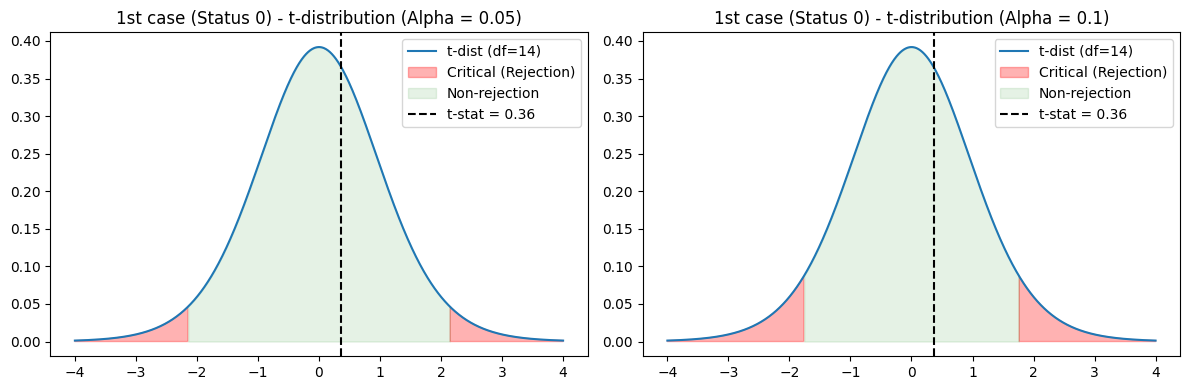

----------------------------------------

=== 2nd case (Status 1) ===
N = 55, df = 54
Hypothesized population mean (mu_0) = 151
Sample mean (x_bar) = 130.00
t-statistic = -8.1255
P-value = 0.0000

For Alpha = 0.05:
Non-rejection region: [-2.0049, 2.0049]
Decision: Reject H_0 (p-value < alpha)

For Alpha = 0.1:
Non-rejection region: [-1.6736, 1.6736]
Decision: Reject H_0 (p-value < alpha)


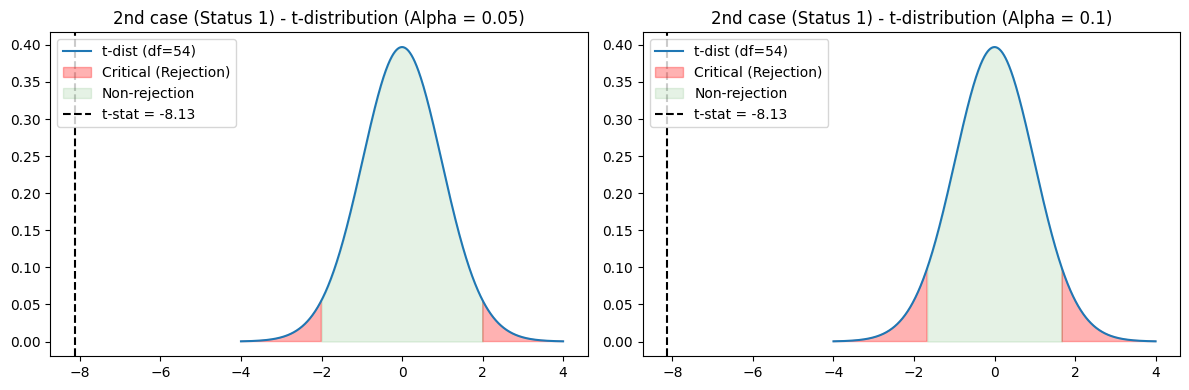

----------------------------------------



In [6]:
# Running the analysis for both cases
perform_hypothesis_test(case1_data, "1st case (Status 0)", case=0)
perform_hypothesis_test(case2_data, "2nd case (Status 1)", case=1)